### DCE Soymeal: Curve vs Outright
Every trade is in M1 (the most-traded contract), using signals from the shape of the curve against M2 and M3 (the next two expiries). Decided at the close, held from the next day.

**Curve baseline trade.** Trades the curve's state. Short M1 when the curve is in contango and the M1–M2 spread has weakened over the last 5 days; long otherwise. Stands aside on days when the divergence trade points the other way, and on days when M3 is not yet listed. In the market about half of all trading days.

**Divergence trade (lead-lag).** The curve tends to move before the outright. If the front of the curve has firmed against M2 and M3 over 5 days but M1 hasn't rallied, go long; the reverse, go short.
- Small divergences (fast leg): held 1 day.
- Large divergences (slow leg): held 5 days.

**Combined book.** Both positions netted into one M1 position.

| | Net Sharpe | Before Jul 2022 | After Jul 2022 |
|---|---|---|---|
| Curve baseline | 0.91 | 0.95 | 0.86 |
| Divergence | 1.47 | 2.27 | 0.81 |
| Combined | 1.40 | 1.82 | 1.04 |

Jun 2019 – Sep 2026, net of 3.5 bps per side. Every trading day counts, including days with no position.

In [30]:
from sklearn.model_selection import GridSearchCV
%load_ext autoreload
%autoreload 2
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from theme import set_theme
set_theme()

import akshare as ak
import utilities as ut
import lead_lag as ll
import lead_lag_plots as llp

The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload


In [44]:
# run strategy analysis for DCE Meal
path = r"C:\Users\Amin\PycharmProjects\Asia Ags\data\raw\dce_meal_data.parquet"

results = ll.run(ll.Config(data_path=path))
results["metrics"]

,fast,slow,lead_lag,baseline_curve_state,combined_1to1
sharpe_net,0.520556,1.365926,1.469978,0.910315,1.397686
sharpe_gross,0.687122,1.443367,1.591169,1.028872,1.531360
ann_return_%,1.976504,12.899826,14.996126,11.836257,27.032044
ann_vol_%,3.796906,9.444016,10.201600,13.002375,19.340570
max_drawdown_%,-6.207431,-18.817427,-16.095155,-18.322793,-21.141825
return_over_dd,0.318409,0.685525,0.931717,0.645985,1.278605
time_in_market,0.041313,0.216186,0.239389,0.458970,0.468591
trades_per_year,9.127334,9.127334,18.397284,19.252971,37.650255
trade_win_rate,0.703125,0.671875,0.689922,0.503704,0.568182
avg_trade_bps,25.154776,144.120862,83.954580,63.059044,72.845120


<Axes: title={'center': 'Trade outcomes: baseline_curve_state'}, xlabel='net return per trade, bps', ylabel='trades'>

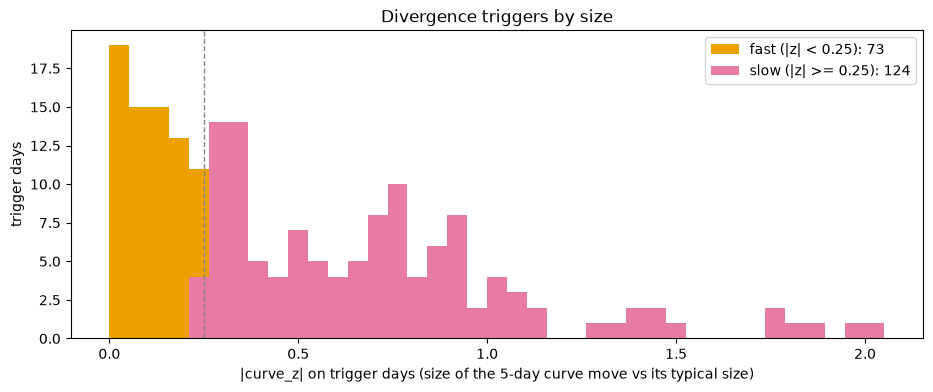

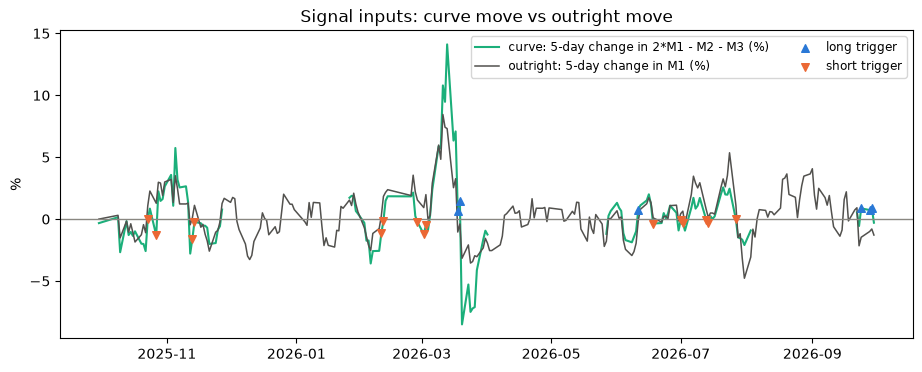

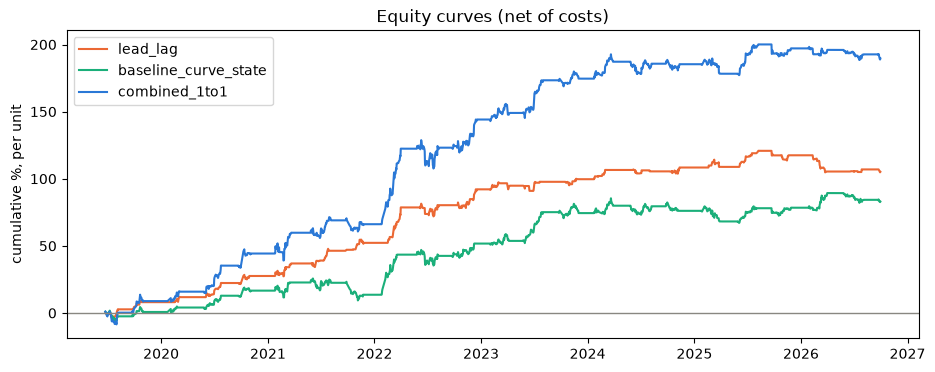

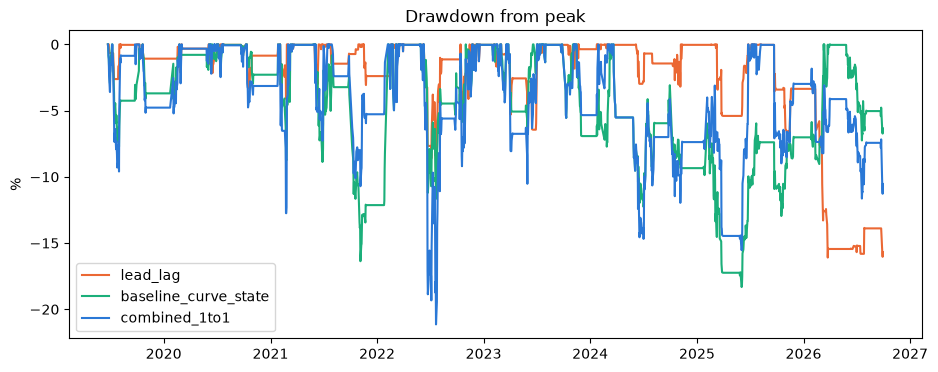

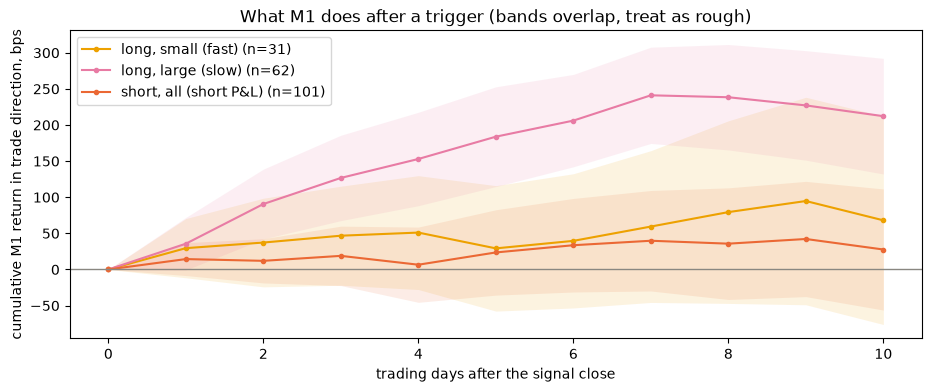

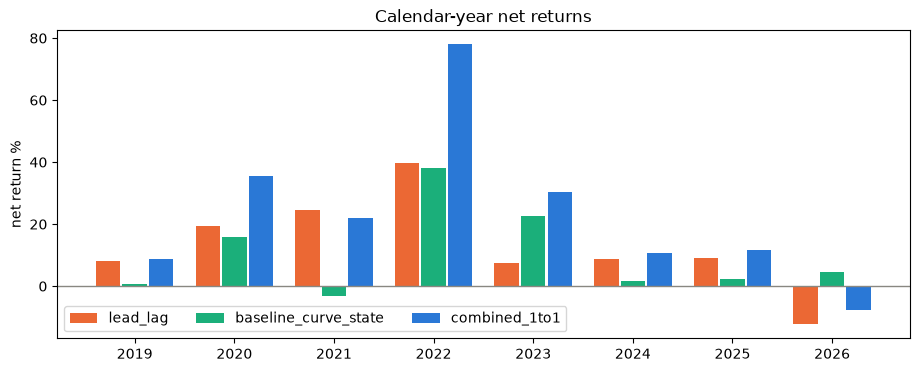

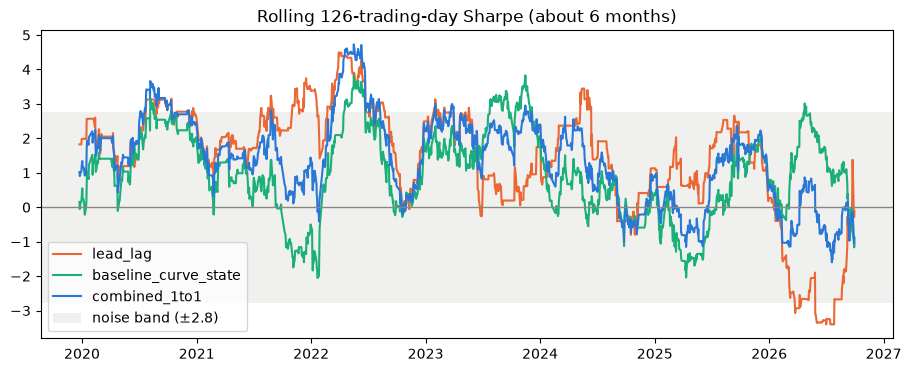

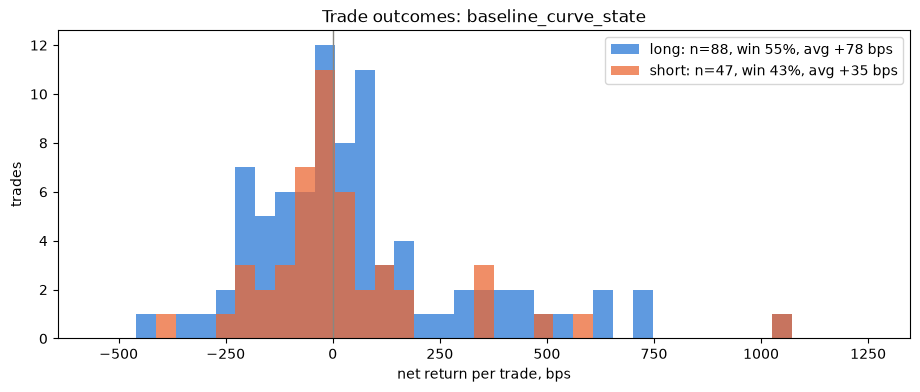

In [55]:
# visualizations

llp.plot_signal_distribution(results)
llp.plot_signal_inputs(results, start="2025-09-30", end="2026-09-30")
llp.plot_equity(results)
llp.plot_drawdown(results)
llp.plot_event_study(results)
llp.plot_yearly(results)
llp.plot_rolling_sharpe(results)
llp.plot_trade_returns(results, book="baseline_curve_state")

In [46]:
# Load
bean_path = r"C:\Users\Amin\PycharmProjects\Asia Ags\data\raw\dce_bean_data.parquet"
df = pd.read_parquet(bean_path)
df

,date,close,volume,hold,contract
0,2018-05-16,3399.0,32,24,B1905
1,2018-05-17,3430.0,8,28,B1905
2,2018-05-18,3410.0,20,40,B1905
3,2018-05-21,3391.0,1664,1658,B1905
4,2018-05-22,3390.0,1678,96,B1905
...,...,...,...,...,...
5612,2026-09-23,3877.0,10,74,B2709
5613,2026-09-24,3871.0,93,126,B2709
5614,2026-09-28,3828.0,25,126,B2709
5615,2026-09-29,3837.0,27,128,B2709


### DCE No.1 Soybeans: same rules, no re-tuning
The soymeal trades run unchanged on No.1 soybeans (B): same signals, same 5-day window, same 1-day and 5-day holds, same costs. Nothing was adjusted to fit beans, so this is a test of whether the meal idea carries over.

| | Net Sharpe | Before Jul 2022 | After Jul 2022 | Worst drawdown |
|---|---|---|---|---|
| Curve baseline | 0.78 | −0.10 | 1.36 | −17% |
| Divergence (fast + slow) | 0.92 | 0.88 | 0.94 | −23% |
| Combined | 1.07 | 0.47 | 1.43 | −23% |
| *Without the 1-day leg:* | | | | |
| Divergence (slow only) | 1.00 | 0.97 | 1.02 | −15% |
| Combined | 1.11 | 0.51 | 1.49 | −18% |

**The large divergences carry over; the small ones do not.**
- When the bean curve moves well ahead of M1, M1 tends to catch up over the following days, just as in meal. This 5-day trade wins about 63% of the time.
- The small divergences that corrected overnight in meal do not correct in beans. The 1-day trade is a coin flip and earns about 5 bps a trade, less than it costs to trade. Taking it out leaves returns unchanged and cuts the worst drawdown from 23% to 18% in the combined book.

**Beans are weaker than meal overall, but steadier since mid-2022.** Meal's divergence trade made most of its money before 2022. Beans made less early on, but held up better since. In beans, the curve-state trade and the divergence trade made their money in different years, so the combined book is the steadiest version.

**2026 is a losing year in both markets.** Most of the loss came in March, during the volatility around the Iran/US conflict, when M1 moved sharply on the news, not on the curve. Outside March, beans lost a further 8%, most of it from the 1-day trade.

Jun 2019 – Sep 2026, net of 3.5 bps per side. Every trading day counts, including days with no position.

In [48]:
# run strategy analysis for DCE Soybeans
soybeans = ll.run(ll.Config(data_path=bean_path))
soybeans["metrics"]

,fast,slow,lead_lag,baseline_curve_state,combined_1to1
sharpe_net,0.036891,0.998971,0.915909,0.779796,1.067179
sharpe_gross,0.207471,1.080576,1.032359,0.918517,1.218411
ann_return_%,0.148754,10.319028,10.647782,10.806455,21.644237
ann_vol_%,4.032277,10.329655,11.625371,13.858052,20.281732
max_drawdown_%,-9.900907,-14.770250,-23.312498,-17.151194,-23.188534
return_over_dd,0.015024,0.698636,0.456741,0.630070,0.933403
time_in_market,0.045351,0.258503,0.289116,0.511338,0.550454
trades_per_year,9.714286,10.000000,19.428571,24.571429,43.428571
trade_win_rate,0.500000,0.628571,0.573529,0.465116,0.539474
avg_trade_bps,4.928351,106.140282,57.198145,45.750106,51.024559


In [49]:
# Bean analysis : Eliminating the fast leg strategy
positions = soybeans["positions"]
bean_cfg = soybeans["config"]
bean_mask = ll.evaluation_days(soybeans["signals"])

no_fast_books = {
    "lead_lag (fast+slow)": positions["lead_lag"],
    "slow only": positions["slow"],
    "baseline_curve_state": positions["baseline_curve_state"],
    "combined (base+fast+slow)": positions["combined_1to1"],
    "combined (base+slow)": positions["baseline_curve_state"] + positions["slow"],
}

no_fast_metrics, no_fast_pnl = {}, {}
for name, position in no_fast_books.items():
    net, gross, held = ll.backtest(position, soybeans["curve"], bean_cfg, bean_mask)
    no_fast_metrics[name] = ll.metrics(net, gross, held, bean_cfg)
    no_fast_pnl[name] = net

no_fast_yearly = pd.DataFrame({name: pnl.groupby(pnl.index.year).sum() * 100 for name, pnl in no_fast_pnl.items()})
display(pd.DataFrame(no_fast_metrics).round(2))
display(no_fast_yearly.round(1))

,lead_lag (fast+slow),slow only,baseline_curve_state,combined (base+fast+slow),combined (base+slow)
sharpe_net,0.92,1.00,0.78,1.07,1.11
sharpe_gross,1.03,1.08,0.92,1.22,1.25
ann_return_%,10.65,10.32,10.81,21.64,21.23
ann_vol_%,11.63,10.33,13.86,20.28,19.14
max_drawdown_%,-23.31,-14.77,-17.15,-23.19,-17.99
return_over_dd,0.46,0.70,0.63,0.93,1.18
time_in_market,0.29,0.26,0.51,0.55,0.54
trades_per_year,19.43,10.00,24.57,43.43,36.29
trade_win_rate,0.57,0.63,0.47,0.54,0.52
avg_trade_bps,57.20,106.14,45.75,51.02,60.08


,lead_lag (fast+slow),slow only,baseline_curve_state,combined (base+fast+slow),combined (base+slow)
date,,,,,
2019,2.2,2.7,-4.3,-2.1,-1.6
2020,12.1,14.8,-3.0,9.2,11.8
2021,12.3,10.8,7.5,20.0,18.5
2022,19.5,16.1,9.3,28.8,25.4
2023,33.7,29.0,42.7,76.6,71.9
2024,6.1,8.9,6.5,12.6,15.4
2025,6.0,2.8,14.8,21.2,17.6
2026,-17.2,-12.7,2.1,-14.9,-10.5


<Axes: title={'center': 'Trade outcomes: lead_lag'}, xlabel='net return per trade, bps', ylabel='trades'>

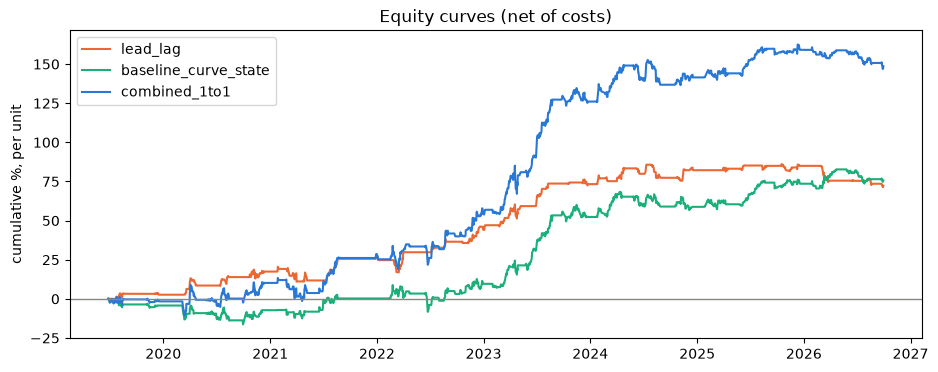

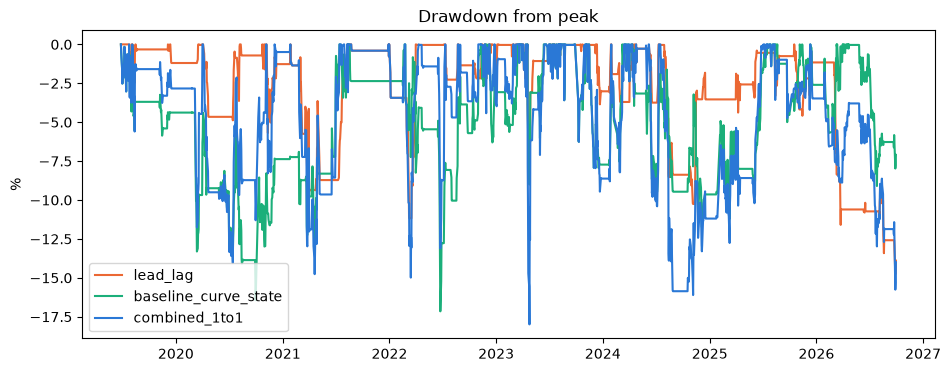

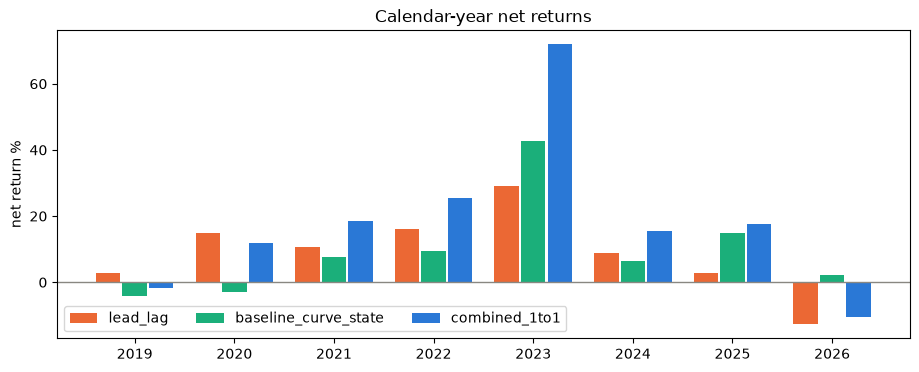

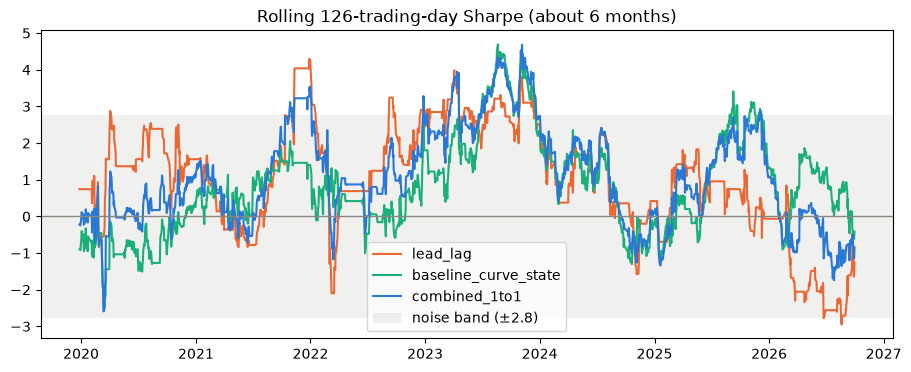

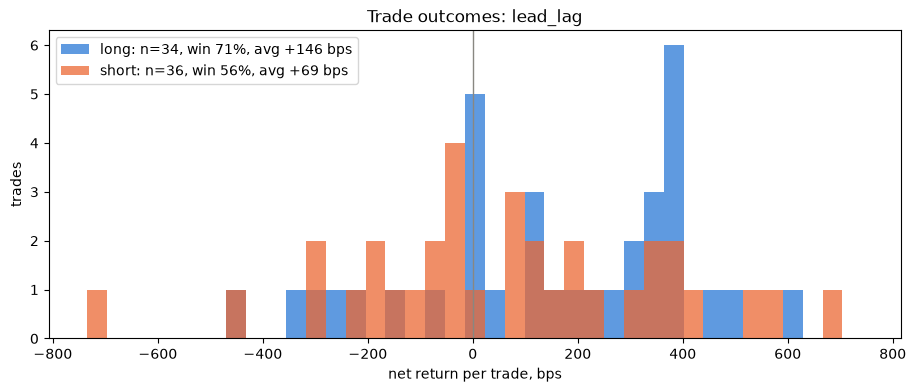

In [50]:
soybeans_no_fast = {
    **soybeans,
    "positions": {**positions,
                  "fast": positions["fast"] * 0,
                  "lead_lag": positions["slow"],
                  "combined_1to1": positions["baseline_curve_state"] + positions["slow"]},
    "pnl": {**soybeans["pnl"],
            "fast": no_fast_pnl["slow only"] * 0,
            "lead_lag": no_fast_pnl["slow only"],
            "combined_1to1": no_fast_pnl["combined (base+slow)"]},
}
soybeans_no_fast["yearly"] = pd.DataFrame({name: pnl.groupby(pnl.index.year).sum() * 100
                                           for name, pnl in soybeans_no_fast["pnl"].items()})

llp.plot_equity(soybeans_no_fast)
llp.plot_drawdown(soybeans_no_fast)
llp.plot_yearly(soybeans_no_fast)
llp.plot_rolling_sharpe(soybeans_no_fast)
llp.plot_trade_returns(soybeans_no_fast, book="lead_lag")

In [51]:
def get_spread_data_akshare(symbols: list[str], columns: list[str]) -> tuple[pd.DataFrame, list[str]]:
    frames, failed = [], []
    for symbol in symbols:
        try:
            df = ak.futures_zh_daily_sina(symbol)
        except ValueError:
            failed.append(symbol)
            continue
        cols_to_keep = [c for c in columns if c in df.columns]
        df = df[cols_to_keep].copy()
        df["contract"] = symbol
        df["date"] = pd.to_datetime(df["date"])
        frames.append(df)
    return pd.concat(frames, ignore_index=True), failed

# symbols
symbols = [f"Y{yy}{mm}" for yy in range(19, 28) for mm in ["01", "05", "09"]]
columns = ["date", "close", "volume", "hold"]

data, failed = get_spread_data_akshare(symbols, columns)

### DCE Soybean Oil: same rules, no re-tuning
The soymeal trades run unchanged on soybean oil (Y). Like meal and beans, oil trades almost entirely in the January, May and September contracts, so the curve is built from the same three months.

| | Net Sharpe | Before Jul 2022 | After Jul 2022 | Worst drawdown |
|---|---|---|---|---|
| Curve baseline | 0.36 | 0.23 | 0.39 | −32% |
| Divergence (fast + slow) | 0.62 | 0.97 | 0.24 | −39% |
| Combined | 0.63 | 0.73 | 0.41 | −61% |
| *Without the 1-day leg:* | | | | |
| Divergence (slow only) | 0.80 | 1.18 | 0.39 | −38% |
| Combined | 0.74 | 0.85 | 0.51 | −57% |

**The idea is much weaker in oil.** The 1-day trade loses money in every period. The 5-day trade made most of its profit in a single year (2021, during the vegoil rally), and its winning trades are no bigger than its losing ones.

**The 2021–22 vegoil shock was the worst stretch of any of the three markets.** The combined book fell 61% from September 2021 to July 2022, and only recovered its previous high in June 2025:
- About a quarter of the fall came before the Russian invasion, during the supply-driven rally in late 2021.
- The invasion months (February–March 2022) cost the divergence trade about 12%.
- The worst single month was July 2022, during the palm-led collapse in vegetable oil prices, when M1 volatility hit 45% a year, about two and a half times a normal month.

Oil prices follow palm oil and crude more than soybeans, so when the outright moves on outside news, the soy curve gives little warning of it. That is the situation in which the divergence trade loses.

Jun 2019 – Sep 2026, net of 3.5 bps per side. Every trading day counts, including days with no position.

In [53]:
# Run oil analysis
oil_path = r"C:\Users\Amin\PycharmProjects\Asia Ags\data\raw\dce_oil_data.parquet"

oil = ll.run(ll.Config(data_path=oil_path))
oil["metrics"]

,fast,slow,lead_lag,baseline_curve_state,combined_1to1
sharpe_net,-0.381668,0.797635,0.615796,0.362616,0.626905
sharpe_gross,-0.226363,0.872659,0.726700,0.463038,0.754381
ann_return_%,-1.904366,10.633865,8.908990,5.308503,14.367069
ann_vol_%,4.989583,13.331739,14.467444,14.639456,22.917465
max_drawdown_%,-22.932416,-37.949586,-38.929708,-32.444368,-61.405835
return_over_dd,-0.083043,0.280210,0.228848,0.163619,0.233969
time_in_market,0.053137,0.342001,0.366309,0.463539,0.490673
trades_per_year,10.968909,12.250989,22.934992,18.091577,40.314302
trade_win_rate,0.441558,0.651163,0.546584,0.472441,0.484099
avg_trade_bps,-14.043310,89.689587,41.192358,31.795154,36.899131


<Axes: title={'center': 'Trade outcomes: slow'}, xlabel='net return per trade, bps', ylabel='trades'>

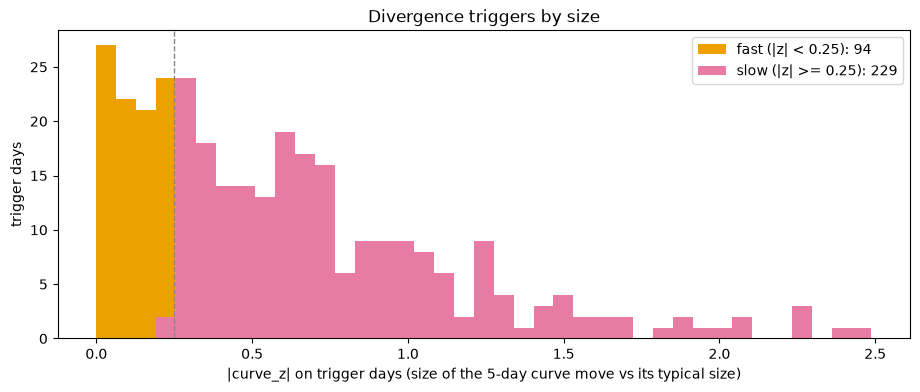

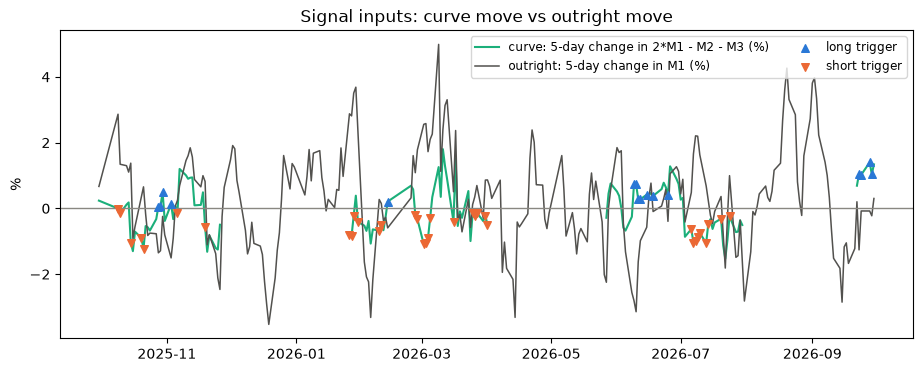

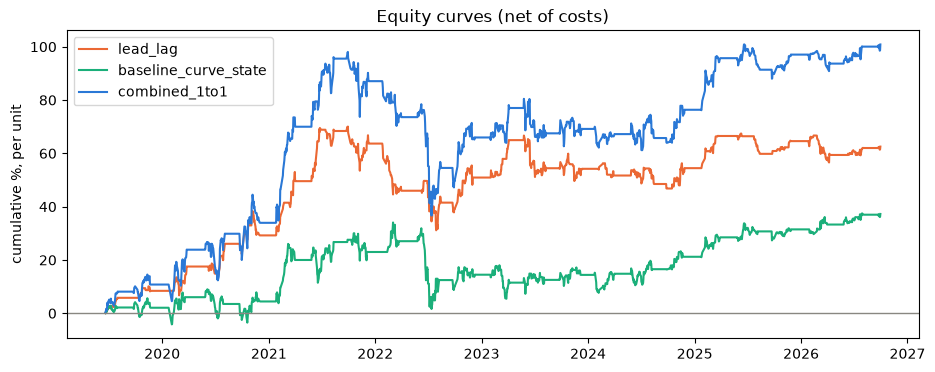

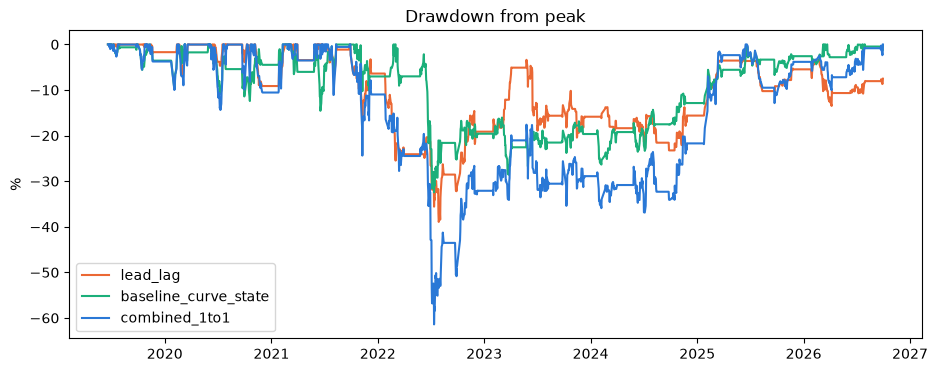

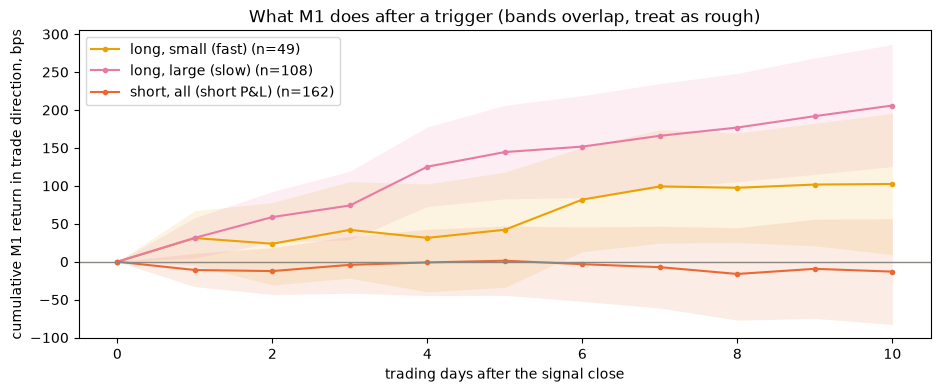

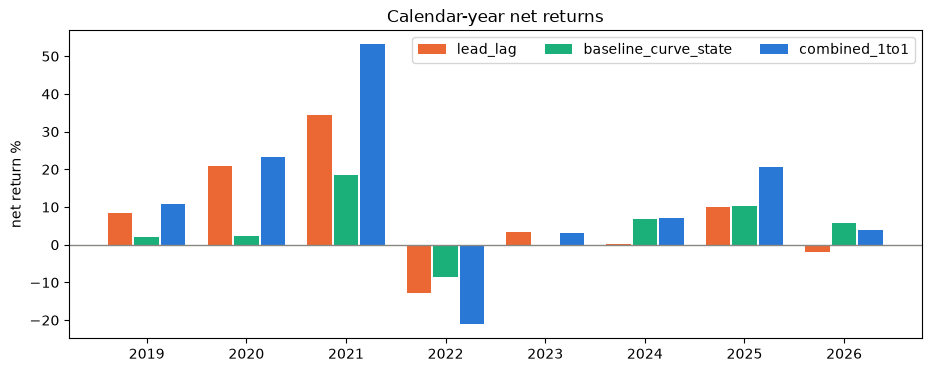

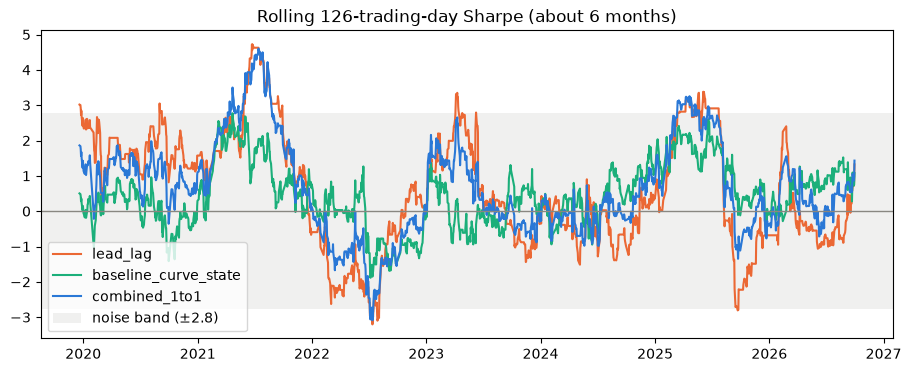

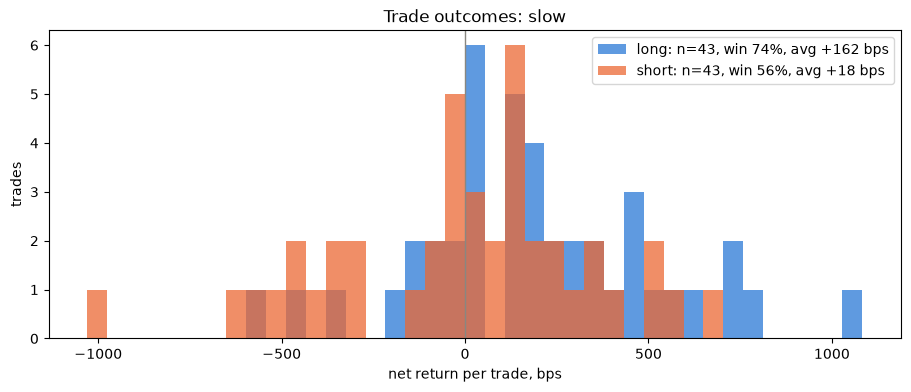

In [54]:
# visualizations

llp.plot_signal_distribution(oil)
llp.plot_signal_inputs(oil, start="2025-09-30", end="2026-09-30")
llp.plot_equity(oil)
llp.plot_drawdown(oil)
llp.plot_event_study(oil)
llp.plot_yearly(oil)
llp.plot_rolling_sharpe(oil)
llp.plot_trade_returns(oil, book="slow")

### Does standing aside in volatile markets help?
In each market the worst losses came during outside shocks: March 2026 in meal and beans, and 2021–22 in oil. A natural fix is to stand aside when the market is unusually volatile. To avoid fitting the rule to those episodes, it was set before looking at the results and applied unchanged to all three markets:

- Measure M1's volatility over the last 20 trading days.
- If it is above the 90th percentile of its own history up to the day before, close every position and stay flat that day.
- The history only uses past data, and the rule switches on after one year of history.

The first table compares each book with and without the filter. The second shows the share of days the filter kept the book out of the market each year.

In [ ]:
vol_runs = {}
for market, data_path in {"meal": path, "beans": bean_path, "oil": oil_path}.items():
    for vol_filter in [False, True]:
        vol_runs[(market, "filtered" if vol_filter else "unfiltered")] = ll.run(ll.Config(data_path=data_path, vol_filter=vol_filter))

rows = ["sharpe_net", "sharpe_before_split", "sharpe_after_split", "max_drawdown_%"]
vol_table = pd.concat({key: out["metrics"].loc[rows, ["slow", "lead_lag", "combined_1to1"]].T for key, out in vol_runs.items()})
display(vol_table.unstack(1).round(2))

flagged = {}
for (market, label), out in vol_runs.items():
    if label == "filtered":
        high_vol = out["high_vol"][ll.evaluation_days(out["signals"])]
        flagged[market] = high_vol.groupby(high_vol.index.year).mean() * 100
display(pd.DataFrame(flagged).round(0))

**The filter does not help, in any market.**

| Net Sharpe, combined book | Unfiltered | Filtered | Worst drawdown, unfiltered → filtered |
|---|---|---|---|
| Meal | 1.40 | 1.15 | −21% → −19% |
| Beans | 1.07 | 0.86 | −23% → −23% |
| Oil | 0.63 | 0.40 | −61% → −44% |

- **It misses the shocks it was meant to catch.** It was never on in 2026. Measured against a history that includes the 2020–22 turbulence, March 2026 was not unusually volatile, and a 20-day measure only rises after the damage is done.
- **It removes good trades.** It kept the books out of the market for between a fifth and two fifths of 2020–22, and in meal and beans those were profitable years for the divergence trade.
- **In oil it softens the 2022 drawdown but costs more than it saves.** The worst drawdown falls from 61% to 44%, but returns fall faster.

The damaging moves arrive suddenly, and a volatility filter only sees them once they have started. The rule stays off. Changing the window or the threshold until it catches March 2026 would be fitting it to one event.

### Curve signal book: one rule, three markets

**What it does.** Each day, look at whether the front contract (M1) has gained or lost against the next contract (M2) over the last 5 days. If M1 has gained on M2, lean long M1; if it has lost, lean short. Positions are in M1 only, run unchanged on soymeal, No.2 soybeans and soybean oil, and held as one equal-weight book.

**Why it works.** The curve is priced by people with physical exposure (crushers, feed mills, stockholders). When the front firms against the deferred contracts, M1 tends to keep rising over the next 1–5 days. The information is in how the curve has just *moved*, not its shape: contango or backwardation on its own predicts nothing, and M1's own 5-day return predicts nothing.

| Input | What it represents |
|---|---|
| M1 | The most-traded contract (highest open interest); every trade is in M1 |
| M2 | The next 01/05/09 contract after M1 |
| `bm5` | M1's 5-day return minus M2's 5-day return: the front's recent move relative to the next contract |
| `sign(bm5)` | +1 if M1 outperformed M2 over 5 days, −1 if it underperformed |
| Position | The average of the last 5 daily signs, so it moves in steps between −1 and +1 and holds about a week |
| Flat days | When M3 is not yet listed (the 1–2 months after each roll), the curve is not scored and that day's sign is 0 |

**Why the sign and not the size.** Ranking `bm5` against its own history (any window from 5 months to 2 years) gave the same results as the plain sign. The size of the move adds nothing, and the sign needs no window to choose or explain.

**Settings, fixed before testing.** 5-day lookback, 5-day hold, decided at the close and held from the next day, 3.5 bps per side plus roll costs. Every lookback and hold between 2 and 10 days scores about the same (average Sharpe 0.75–1.16), so 5×5 is not a fitted peak.

| Aug 2019 – Sep 2026, net | Sharpe | Before / after Jul 2022 | Annual return | Annual vol | Worst drawdown |
|---|---|---|---|---|---|
| Meal | 0.94 | 1.48 / 0.57 | 9.2% | 9.8% | −15.8% |
| No.2 beans | 0.91 | 0.46 / 1.20 | 9.4% | 10.3% | −12.5% |
| Soybean oil | 1.06 | 1.38 / 0.80 | 11.7% | 11.1% | −12.4% |
| **Book, equal weight** | **1.43** | **1.79 / 1.21** | **10.1%** | **7.1%** | **−7.7%** |

| Daily P&L correlation | Meal | Beans | Oil |
|---|---|---|---|
| Meal | 1 | 0.44 | 0.00 |
| Beans | | 1 | 0.16 |

| Book net return | 2019 | 2020 | 2021 | 2022 | 2023 | 2024 | 2025 | 2026 |
|---|---|---|---|---|---|---|---|---|
| % | 1.0 | 7.6 | 15.6 | 24.0 | 24.4 | 1.0 | 0.5 | −4.2 |

**Reading it.**
- The book beats each market because the three bets are nearly independent: meal and oil are uncorrelated, since their curves answer to different drivers (feed demand against palm and energy).
- Each market breaks even at about 30–38 bps per side, so costs are not the constraint.
- Against the two-rule combined book above: lower Sharpe in meal and beans, higher in oil (1.06 vs 0.59), and a smaller worst drawdown in every market (oil −12% vs −61%; oil 2022 +23% vs −21%).
- As a three-market book the two-rule version scores the same (Sharpe 1.48 vs 1.43), at twice the volatility (14.4% vs 7.1%) and a −19% worst drawdown. It has held up better since 2024 (Sharpe 0.74 vs −0.17). A 50/50 blend of the two scored 1.39, so combining them adds nothing.

**Open points.**
- 2024–2026 is flat for this book; almost all the return is 2020–2023.
- Oil is not fully out of sample: `bm5` was chosen after a test that included oil.
- No.2 beans are thin, which limits size in that market.
- Next test: the same frozen rule on ZCE rapeseed meal (RM) and rapeseed oil (OI), which played no part in any choice.

In [ ]:
runs = {"meal": results, "bean": soybeans, "oil": oil}
signal_book = ll.book(runs, "curve_signal", start="2019-08-01")
original_book = ll.book(runs, "combined_1to1", start="2019-08-01")

display(signal_book["metrics"].round(2))
display(signal_book["correlation"].round(2))
display(signal_book["yearly"].round(1))
display(original_book["metrics"].round(2))